## Vanilla DIP 

In [5]:
print("hello world")


hello world


In [7]:
!pip install bm3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.0/862.0 kB 17.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 38.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [bm3d]━━━━━━━━━━━━━ 2/3 [bm3d]


Running BM3D on BSDS300 for denoise
PSNR_noisy: 26.200379816421734,  PSRN_gt: 39.56478421242656
SSIM_gt: 0.9679882526397705,  SSIM_noisy: 0.34826233983039856,  DSSIM: 0.2437858971740652


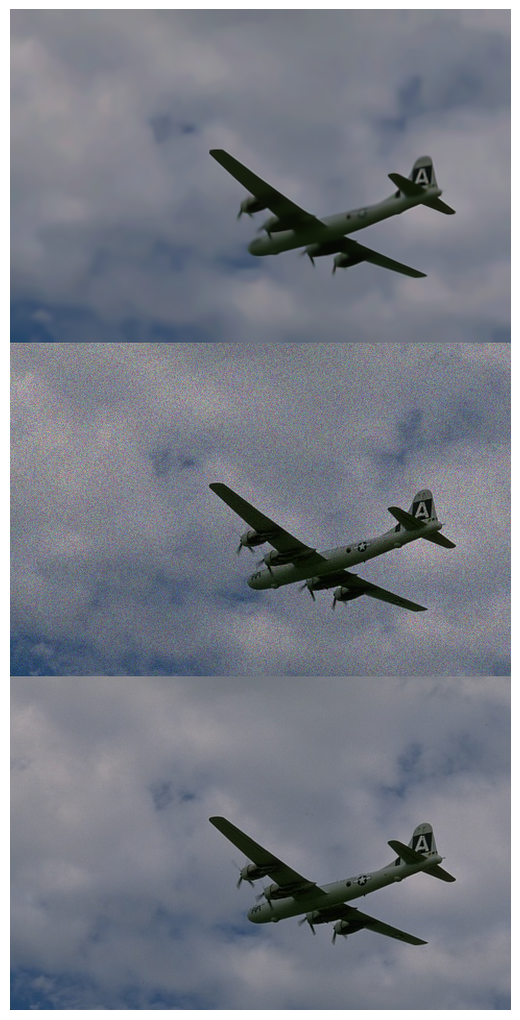

Finished running BM3D on BSDS300 for denoise


In [10]:
from run_dip_denoise_deblur import *

dataset = BSDS300Dataset(use_patches=False)
run_method(dataset, dataset_name="BSDS300", task="denoise", method="BM3D", fsavepath="../results", verbose=True, sigma=0.1)

cuda:0
cuda:0
Running DIP on BSDS300 for denoise
Number of params: 2212671
Starting optimization with ADAM


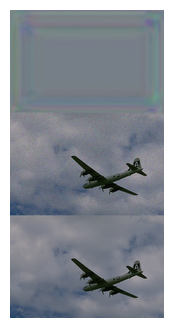

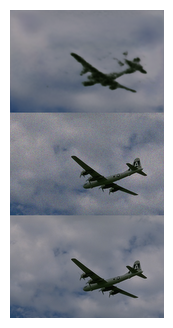

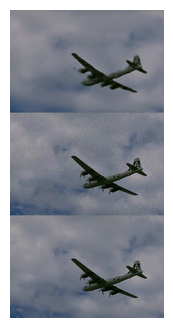

Iteration 00202  Loss 0.003118  PSNR_noisy: 23.59  PSNR_gt: 29.58  SSIM_gt: 0.9228  DSSIM: 0.1340
Early stopping at iteration 202; restoring best checkpoint from iteration 182.
Finished running DIP on BSDS300 for denoise


In [1]:
from run_dip_denoise_deblur import *

dataset = BSDS300Dataset(use_patches=False)
run_method(dataset, dataset_name="BSDS300", task="denoise", method= "DIP", fsavepath="../results", verbose=True, sigma=0.1)



In [ ]:
import importlib
import run_dip_denoise_deblur as dip_runner
from IPython.display import display, Image as NotebookImage

# Reload so notebook sessions pick up the latest comparison implementation.
dip_runner = importlib.reload(dip_runner)

dataset = dip_runner.BSDS300Dataset(use_patches=False)
comparison = dip_runner.compare_admm_tv_methods(
    dataset,
    image_index=0,       # Change this to compare another dataset image.
    sigma=0.1,
    fsavepath="../results",
    verbose=False,       # Avoid intermediate plots from every iteration.
    noise_seed=1,        # Both methods receive the same noisy image.
    model_seed=1,        # Equivalent layers start from the same seed.
)

# Display the combined outputs and the metric-curve comparison.
display(NotebookImage(filename=comparison["montage_path"]))
display(NotebookImage(filename=comparison["curves_path"]))

The comparison uses one deterministic image and one shared speckle-noise realization. The saved montage contains the ground truth, noisy observation, ADMM-DIP-TV output, and ADMM-DIP-WTV output. Results are written to `../results/denoise/ADMM-comparison/`.